# Training

In [1]:
import pennylane as qml
import numpy as np
import torch
from qvc_model import HybridModel
from noise_models import depolarising_single_qubit, depolarising_two_qubit
import pickle
from torchvision import transforms
import torchvision

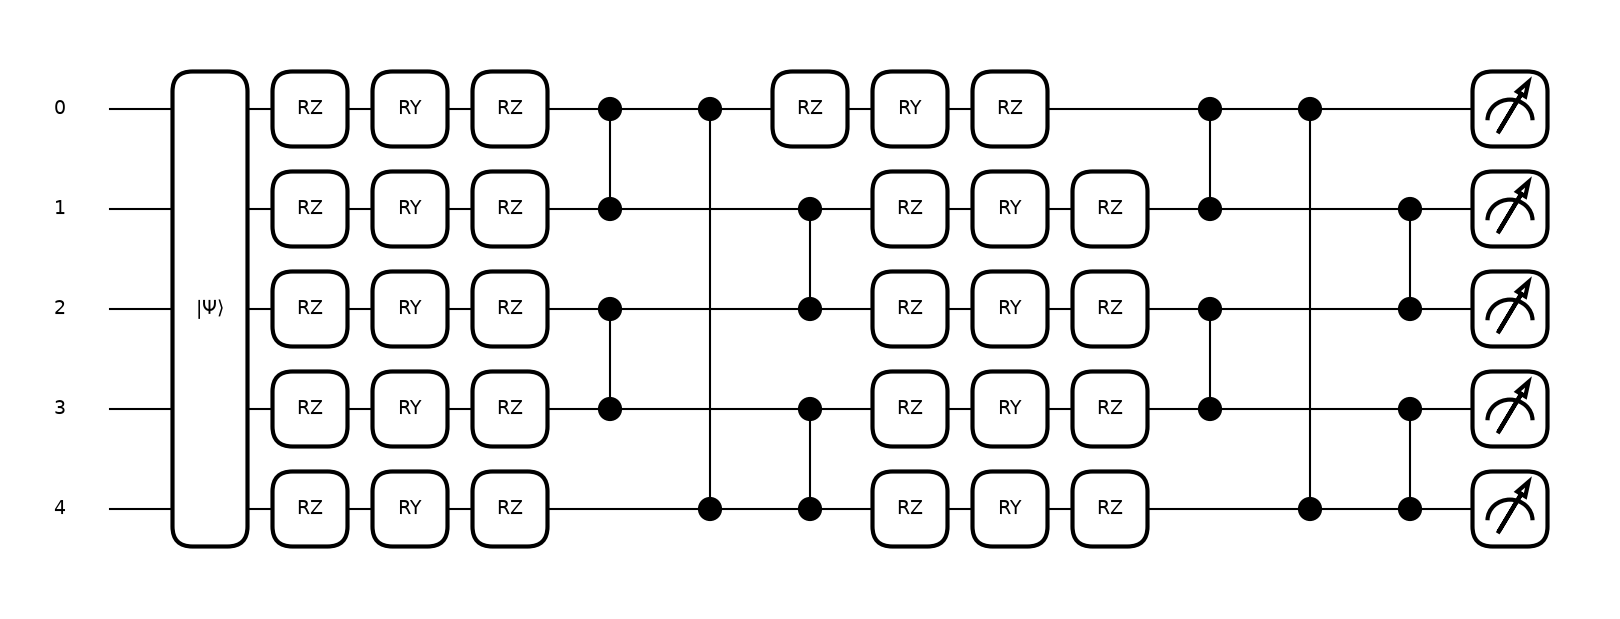

In [ ]:
# Get circuit drawing of the quantum circuit for 4 qubits and 2 layers
from qvc_model import HybridModel
import pennylane as qml
import torch
import pennylane.numpy as np
import matplotlib.pyplot as plt

num_qubits = 5
# Create a hybrid model instance
dev = qml.device("default.qubit", wires=num_qubits)
model = HybridModel(dev, device=torch.device("cpu"), num_qubits=num_qubits, weight_shapes={"weights": (2, num_qubits, 3)})
model_circuit = model.quantum_circuit

# Generate fake inputs and weights to initialise the circuit
inputs = np.random.rand(32)  # input values
weights = np.random.rand(2, num_qubits, 3)  # 2 layers

qml.draw_mpl(model_circuit)(inputs, weights)  # Draw the circuit with the generated inputs and weights
plt.show()

In [4]:
phi = {f"{P}{Q}": 0.0 for P in "IXYZ" for Q in "IXYZ" if not (P == "I" and Q == "I")}
phi["ZZ"] = 0.00116
print(phi)

{'IX': 0.0, 'IY': 0.0, 'IZ': 0.0, 'XI': 0.0, 'XX': 0.0, 'XY': 0.0, 'XZ': 0.0, 'YI': 0.0, 'YX': 0.0, 'YY': 0.0, 'YZ': 0.0, 'ZI': 0.0, 'ZX': 0.0, 'ZY': 0.0, 'ZZ': 0.00116}


In [9]:
depol_noise_model = depolarising_single_qubit(p_depol=0.01)
print(str(depol_noise_model))

NoiseModel({
    OpEq(RY): DepolarizingChannel(p=0.01)
})
